# DKTC EDA - 한국어 위협 대화 분류
**Dataset of Korean Threatening Conversations**

5개 클래스 분류: 협박, 갈취, 직장 내 괴롭힘, 기타 괴롭힘, 일반 대화

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (macOS)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('Set2')

# 데이터 로드
DATA_DIR = 'aiffel-d-lthon-dktc-online-17'
train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
submission = pd.read_csv(f'{DATA_DIR}/submission.csv')

print(f'Train: {train.shape}, Test: {test.shape}, Submission: {submission.shape}')
print(f'\nTrain columns: {list(train.columns)}')
print(f'Test columns: {list(test.columns)}')
train.head()

Train: (3950, 3), Test: (500, 2), Submission: (500, 2)

Train columns: ['idx', 'class', 'conversation']
Test columns: ['idx', 'conversation']


,idx,class,conversation
0,0,협박 대화,지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 ...
1,1,협박 대화,길동경찰서입니다.\n9시 40분 마트에 폭발물을 설치할거다.\n네?\n똑바로 들어 ...
2,2,기타 괴롭힘 대화,너 되게 귀여운거 알지? 나보다 작은 남자는 첨봤어.\n그만해. 니들 놀리는거 재미...
3,3,갈취 대화,어이 거기\n예??\n너 말이야 너. 이리 오라고\n무슨 일.\n너 옷 좋아보인다?...
4,4,갈취 대화,저기요 혹시 날이 너무 뜨겁잖아요? 저희 회사에서 이 선크림 파는데 한 번 손등에 ...


## 1. 클래스 분포 분석

클래스별 샘플 수:
class
기타 괴롭힘 대화      1094
갈취 대화           981
직장 내 괴롭힘 대화     979
협박 대화           896
Name: count, dtype: int64

총 샘플: 3950


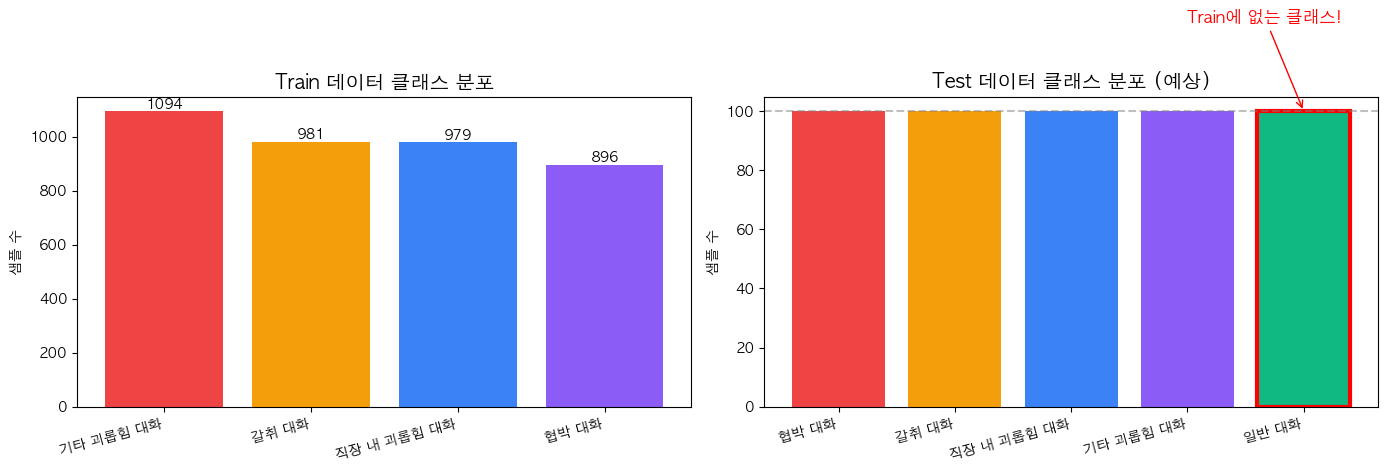

In [2]:
class_counts = train['class'].value_counts()
print('클래스별 샘플 수:')
print(class_counts)
print(f'\n총 샘플: {len(train)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train 클래스 분포
colors = ['#ef4444', '#f59e0b', '#3b82f6', '#8b5cf6']
bars = axes[0].bar(range(len(class_counts)), class_counts.values, color=colors)
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels(class_counts.index, rotation=15, ha='right')
axes[0].set_title('Train 데이터 클래스 분포', fontsize=14, fontweight='bold')
axes[0].set_ylabel('샘플 수')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
                str(val), ha='center', fontweight='bold')

# Test 클래스 분포 (5개 클래스, 각 100개 예상)
test_classes = ['협박 대화', '갈취 대화', '직장 내 괴롭힘 대화', '기타 괴롭힘 대화', '일반 대화']
test_counts = [100] * 5
colors_test = ['#ef4444', '#f59e0b', '#3b82f6', '#8b5cf6', '#10b981']
bars2 = axes[1].bar(range(5), test_counts, color=colors_test)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(test_classes, rotation=15, ha='right')
axes[1].set_title('Test 데이터 클래스 분포 (예상)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('샘플 수')
axes[1].axhline(y=100, color='gray', linestyle='--', alpha=0.5)
# 일반 대화 강조
bars2[4].set_edgecolor('red')
bars2[4].set_linewidth(3)
axes[1].annotate('Train에 없는 클래스!', xy=(4, 100), xytext=(3, 130),
                arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 대화 길이 분석

In [3]:
# 길이 피처 추가
train['char_len'] = train['conversation'].str.len()
train['word_count'] = train['conversation'].str.split().apply(len)
train['utterance_count'] = train['conversation'].str.count('\n') + 1
test['char_len'] = test['conversation'].str.len()
test['word_count'] = test['conversation'].str.split().apply(len)

print('=== Train 길이 통계 (문자 수) ===')
print(train.groupby('class')['char_len'].describe().round(1))
print(f'\n=== Test 길이 통계 (문자 수) ===')
print(test['char_len'].describe().round(1))

=== Train 길이 통계 (문자 수) ===
              count   mean    std   min    25%    50%    75%    max
class                                                              
갈취 대화         981.0  216.2   99.7  45.0  147.0  191.0  264.0  678.0
기타 괴롭힘 대화    1094.0  210.1  104.9  41.0  143.0  185.0  246.0  874.0
직장 내 괴롭힘 대화   979.0  237.6  103.6  41.0  167.5  217.0  282.5  843.0
협박 대화         896.0  246.1  106.0  57.0  176.0  220.0  288.0  818.0

=== Test 길이 통계 (문자 수) ===
count    500.0
mean     213.6
std      101.2
min       68.0
25%      143.0
50%      189.0
75%      253.5
max      722.0
Name: char_len, dtype: float64


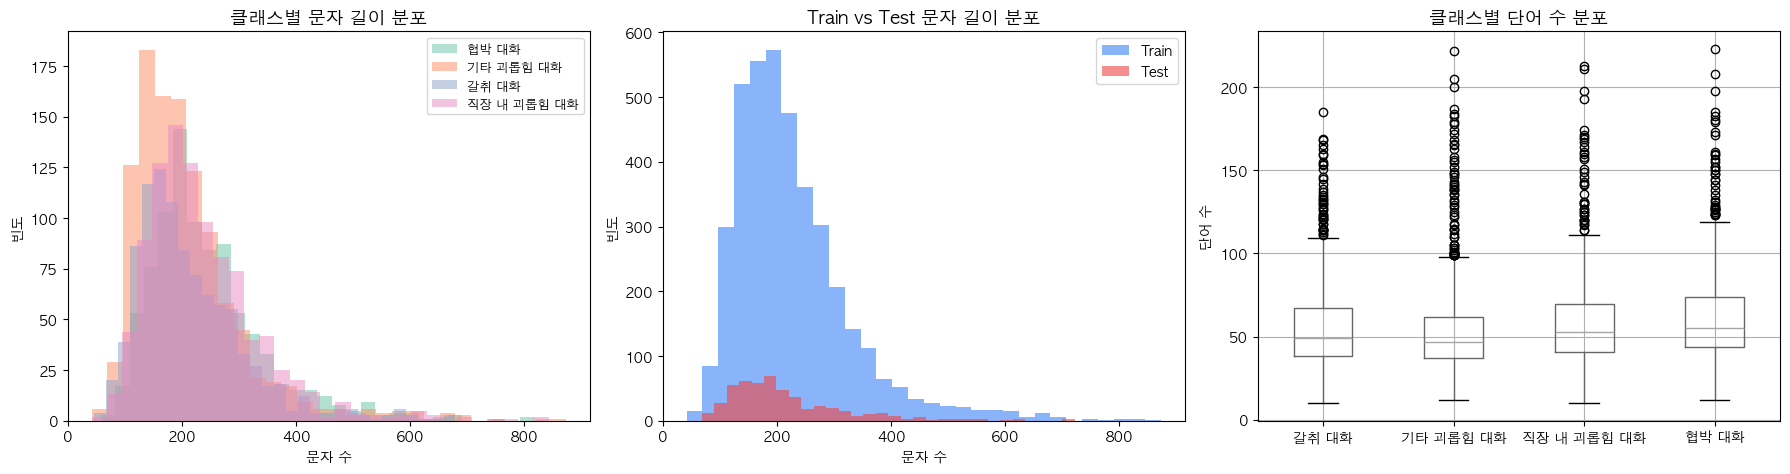

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 클래스별 문자 길이 분포
for cls in train['class'].unique():
    subset = train[train['class'] == cls]
    axes[0].hist(subset['char_len'], bins=30, alpha=0.5, label=cls)
axes[0].set_title('클래스별 문자 길이 분포', fontsize=13, fontweight='bold')
axes[0].set_xlabel('문자 수')
axes[0].set_ylabel('빈도')
axes[0].legend(fontsize=9)

# Train vs Test 길이 비교
axes[1].hist(train['char_len'], bins=30, alpha=0.6, label='Train', color='#3b82f6')
axes[1].hist(test['char_len'], bins=30, alpha=0.6, label='Test', color='#ef4444')
axes[1].set_title('Train vs Test 문자 길이 분포', fontsize=13, fontweight='bold')
axes[1].set_xlabel('문자 수')
axes[1].set_ylabel('빈도')
axes[1].legend()

# 클래스별 단어 수 boxplot
train.boxplot(column='word_count', by='class', ax=axes[2])
axes[2].set_title('클래스별 단어 수 분포', fontsize=13, fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('단어 수')
plt.suptitle('')

plt.tight_layout()
plt.savefig('figures/02_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Train/Test 포맷 차이 분석 (핵심 발견)

Train - 줄바꿈 포함: 3950/3950 (100.0%)
Test  - 줄바꿈 포함: 24/500 (4.8%)


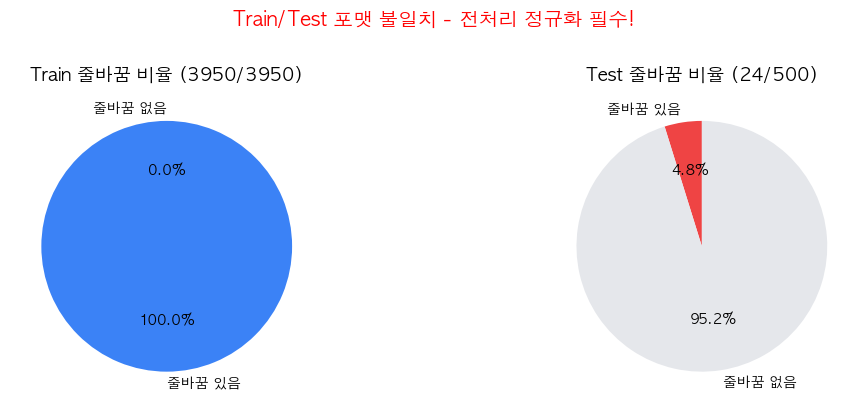


=== Train 예시 (줄바꿈으로 발화 구분) ===
'지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 거면 혼자 죽지 우리까지 사건에 휘말리게 해? 진짜 죽여버리고 싶게.\n 정말 잘못했습니다.\n 너가 선택해. 너가 죽을래 네 가족을 죽여줄까.\n 죄송합니다. 정말 잘못했습니다.\n 너에게는 선택권이 없어. 선택 못한다면 너와 네 가족까지 모조리 죽여버릴거야.\n 선택 못하겠습니다. 한'

=== Test 예시 (공백으로 이어짐) ===
'아가씨 담배한갑주소 네 4500원입니다 어 네 지갑어디갔지 에이 버스에서 잃어버렸나보네 그럼 취소할까요 아가씨 내 여기단골이니 담에 갖다줄께 저도 알바생이라 외상안됩니다 아따 누가 떼먹는다고 그러나 갖다준다고 안됩니다 자꾸이럼 경찰불러요 아가씨 담배피는교 그건 왜 물으세요 그람 아가씨 담배 한대만 빌립시다 내 지금 지갑도 잃어버리고 기분이 그래서 그러니 여'


In [5]:
# Newline 포함 여부 분석
train_has_newline = train['conversation'].str.contains('\n').sum()
test_has_newline = test['conversation'].str.contains('\n').sum()

print(f'Train - 줄바꿈 포함: {train_has_newline}/{len(train)} ({train_has_newline/len(train)*100:.1f}%)')
print(f'Test  - 줄바꿈 포함: {test_has_newline}/{len(test)} ({test_has_newline/len(test)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 파이차트
axes[0].pie([train_has_newline, len(train)-train_has_newline], 
           labels=['줄바꿈 있음', '줄바꿈 없음'], autopct='%1.1f%%',
           colors=['#3b82f6', '#e5e7eb'], startangle=90)
axes[0].set_title(f'Train 줄바꿈 비율 ({train_has_newline}/{len(train)})', fontsize=13, fontweight='bold')

axes[1].pie([test_has_newline, len(test)-test_has_newline], 
           labels=['줄바꿈 있음', '줄바꿈 없음'], autopct='%1.1f%%',
           colors=['#ef4444', '#e5e7eb'], startangle=90)
axes[1].set_title(f'Test 줄바꿈 비율 ({test_has_newline}/{len(test)})', fontsize=13, fontweight='bold')

plt.suptitle('Train/Test 포맷 불일치 - 전처리 정규화 필수!', 
            fontsize=14, fontweight='bold', color='red', y=1.02)
plt.tight_layout()
plt.savefig('figures/03_newline_mismatch.png', dpi=150, bbox_inches='tight')
plt.show()

# 예시 비교
print('\n=== Train 예시 (줄바꿈으로 발화 구분) ===')
print(repr(train['conversation'].iloc[0][:200]))
print('\n=== Test 예시 (공백으로 이어짐) ===')
print(repr(test['conversation'].iloc[0][:200]))

## 4. 중복 데이터 분석

In [6]:
# 중복 대화 확인
duplicates = train[train.duplicated(subset='conversation', keep=False)]
n_unique = train['conversation'].nunique()
n_dup = len(train) - n_unique

print(f'총 샘플: {len(train)}')
print(f'고유 대화: {n_unique}')
print(f'중복 대화: {n_dup}')

if n_dup > 0:
    print(f'\n클래스별 중복 수:')
    dup_by_class = duplicates.groupby('class').size()
    print(dup_by_class)
    
    print(f'\n중복 대화 예시:')
    dup_convs = train[train.duplicated(subset='conversation', keep=False)].sort_values('conversation')
    print(dup_convs[['class', 'conversation']].head(4))

총 샘플: 3950
고유 대화: 3846
중복 대화: 104

클래스별 중복 수:
class
갈취 대화           16
기타 괴롭힘 대화      166
직장 내 괴롭힘 대화     18
협박 대화            8
dtype: int64

중복 대화 예시:
      class                                       conversation
2625  갈취 대화  100만원만 어떻게 해주라.\n저 번에 빌린 돈도 안 갚았잖아. 그 동안 빌린 돈이...
3071  갈취 대화  100만원만 어떻게 해주라.\n저 번에 빌린 돈도 안 갚았잖아. 그 동안 빌린 돈이...
900   협박 대화  5년전 너가 나한테 상처줬던 말들 다 사과해\n내가 너한테 뭘 어쨌는데?\n가해자는...
1426  협박 대화  5년전 너가 나한테 상처줬던 말들 다 사과해\n내가 너한테 뭘 어쨌는데?\n가해자는...


## 5. 클래스별 핵심 키워드 분석 (TF-IDF)

In [7]:
def get_top_tfidf_words(corpus, class_labels, top_n=15):
    """클래스별 TF-IDF 상위 키워드 추출"""
    results = {}
    classes = sorted(class_labels.unique())
    
    for cls in classes:
        # 해당 클래스의 텍스트를 하나로 합침
        cls_texts = corpus[class_labels == cls]
        other_texts = corpus[class_labels != cls]
        
        tfidf = TfidfVectorizer(max_features=5000, token_pattern=r'[가-힣]+')
        all_texts = pd.concat([cls_texts, other_texts])
        tfidf_matrix = tfidf.fit_transform(all_texts)
        
        # 해당 클래스의 평균 TF-IDF
        cls_mean = tfidf_matrix[:len(cls_texts)].mean(axis=0).A1
        other_mean = tfidf_matrix[len(cls_texts):].mean(axis=0).A1
        
        # 차이가 큰 단어 = 해당 클래스의 특징적 단어
        diff = cls_mean - other_mean
        feature_names = tfidf.get_feature_names_out()
        top_idx = diff.argsort()[-top_n:][::-1]
        
        results[cls] = [(feature_names[i], round(diff[i], 4)) for i in top_idx]
    
    return results

# TF-IDF 분석
tfidf_results = get_top_tfidf_words(train['conversation'], train['class'])

for cls, words in tfidf_results.items():
    print(f'\n[{cls}] 상위 키워드:')
    for word, score in words[:10]:
        print(f'  {word}: {score:.4f}')


[갈취 대화] 상위 키워드:
  돈: 0.0632
  내놔: 0.0280
  돈이: 0.0265
  없어요: 0.0224
  안돼: 0.0211
  이거: 0.0195
  만원: 0.0184
  나: 0.0176
  없어: 0.0159
  만원만: 0.0148

[기타 괴롭힘 대화] 상위 키워드:
  야: 0.0227
  그만해: 0.0173
  고객님: 0.0167
  왜: 0.0155
  응: 0.0148
  너: 0.0143
  아: 0.0141
  손님: 0.0137
  아니야: 0.0105
  하지마: 0.0104

[직장 내 괴롭힘 대화] 상위 키워드:
  죄송합니다: 0.0577
  네: 0.0494
  부장님: 0.0296
  아닙니다: 0.0216
  김대리: 0.0198
  제가: 0.0185
  과장님: 0.0178
  일: 0.0177
  회사: 0.0171
  알겠습니다: 0.0159

[협박 대화] 상위 키워드:
  제발: 0.0266
  살려주세요: 0.0183
  내가: 0.0175
  니: 0.0150
  너: 0.0148
  내: 0.0128
  죽여버릴거야: 0.0120
  니가: 0.0116
  당장: 0.0104
  죽고: 0.0101


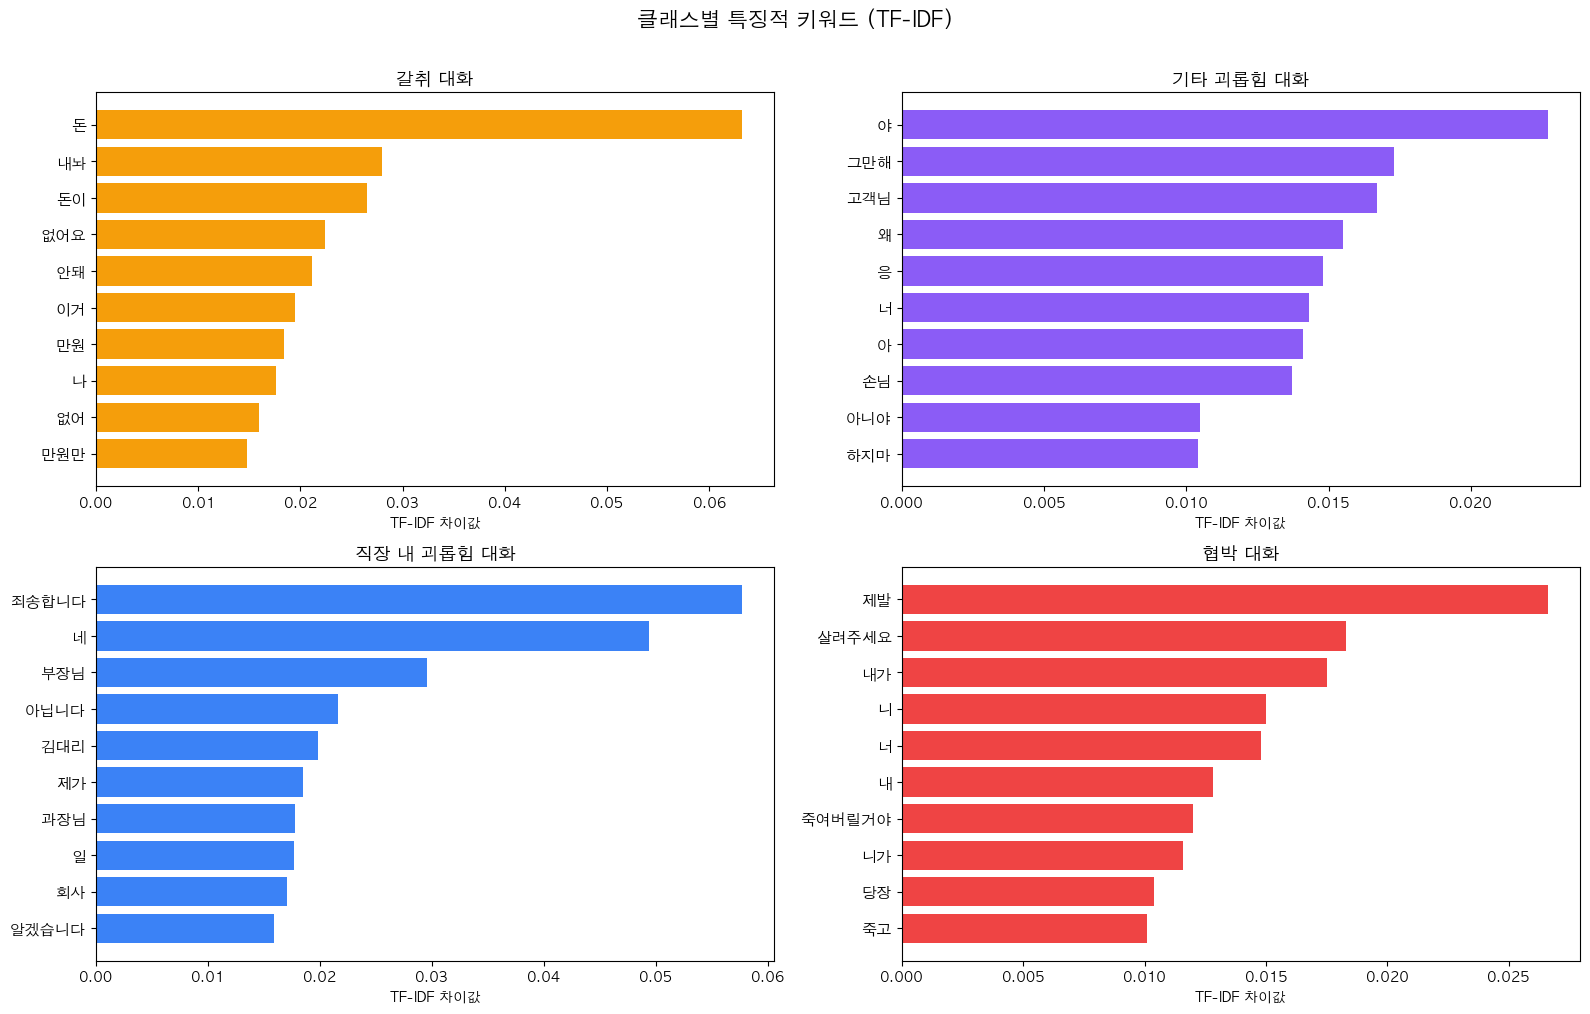

In [8]:
# 클래스별 키워드 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
class_colors = {'갈취 대화': '#f59e0b', '기타 괴롭힘 대화': '#8b5cf6', 
                '직장 내 괴롭힘 대화': '#3b82f6', '협박 대화': '#ef4444'}

for ax, (cls, words) in zip(axes.flat, tfidf_results.items()):
    top10 = words[:10]
    word_labels = [w[0] for w in top10]
    scores = [w[1] for w in top10]
    
    bars = ax.barh(range(len(word_labels)), scores, color=class_colors.get(cls, '#666'))
    ax.set_yticks(range(len(word_labels)))
    ax.set_yticklabels(word_labels, fontsize=11)
    ax.set_title(f'{cls}', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel('TF-IDF 차이값')

plt.suptitle('클래스별 특징적 키워드 (TF-IDF)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/04_tfidf_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 주요 키워드 출현 빈도

In [9]:
# 클래스별 핵심 키워드 출현율
keywords = {
    '협박 대화': ['죽', '죽여', '칼', '살려', '피', '불'],
    '갈취 대화': ['돈', '내놔', '만원', '지갑', '빌려', '갚'],
    '직장 내 괴롭힘 대화': ['회사', '부장', '과장', '야근', '월급', '상사'],
    '기타 괴롭힘 대화': ['못생', '찐따', '왕따', '놀리', '싫어', '꺼져']
}

print('클래스별 핵심 키워드 출현율 (%):\n')
for cls, kws in keywords.items():
    subset = train[train['class'] == cls]['conversation']
    total = len(subset)
    print(f'[{cls}] (n={total})')
    for kw in kws:
        count = subset.str.contains(kw).sum()
        pct = count / total * 100
        print(f'  "{kw}": {count}건 ({pct:.1f}%)')
    print()

클래스별 핵심 키워드 출현율 (%):

[협박 대화] (n=896)
  "죽": 551건 (61.5%)
  "죽여": 219건 (24.4%)
  "칼": 126건 (14.1%)
  "살려": 166건 (18.5%)
  "피": 109건 (12.2%)
  "불": 102건 (11.4%)

[갈취 대화] (n=981)
  "돈": 651건 (66.4%)
  "내놔": 230건 (23.4%)
  "만원": 272건 (27.7%)
  "지갑": 67건 (6.8%)
  "빌려": 217건 (22.1%)
  "갚": 98건 (10.0%)

[직장 내 괴롭힘 대화] (n=979)
  "회사": 309건 (31.6%)
  "부장": 186건 (19.0%)
  "과장": 135건 (13.8%)
  "야근": 38건 (3.9%)
  "월급": 45건 (4.6%)
  "상사": 93건 (9.5%)

[기타 괴롭힘 대화] (n=1094)
  "못생": 66건 (6.0%)
  "찐따": 52건 (4.8%)
  "왕따": 20건 (1.8%)
  "놀리": 41건 (3.7%)
  "싫어": 95건 (8.7%)
  "꺼져": 49건 (4.5%)



## 7. WordCloud (클래스별)

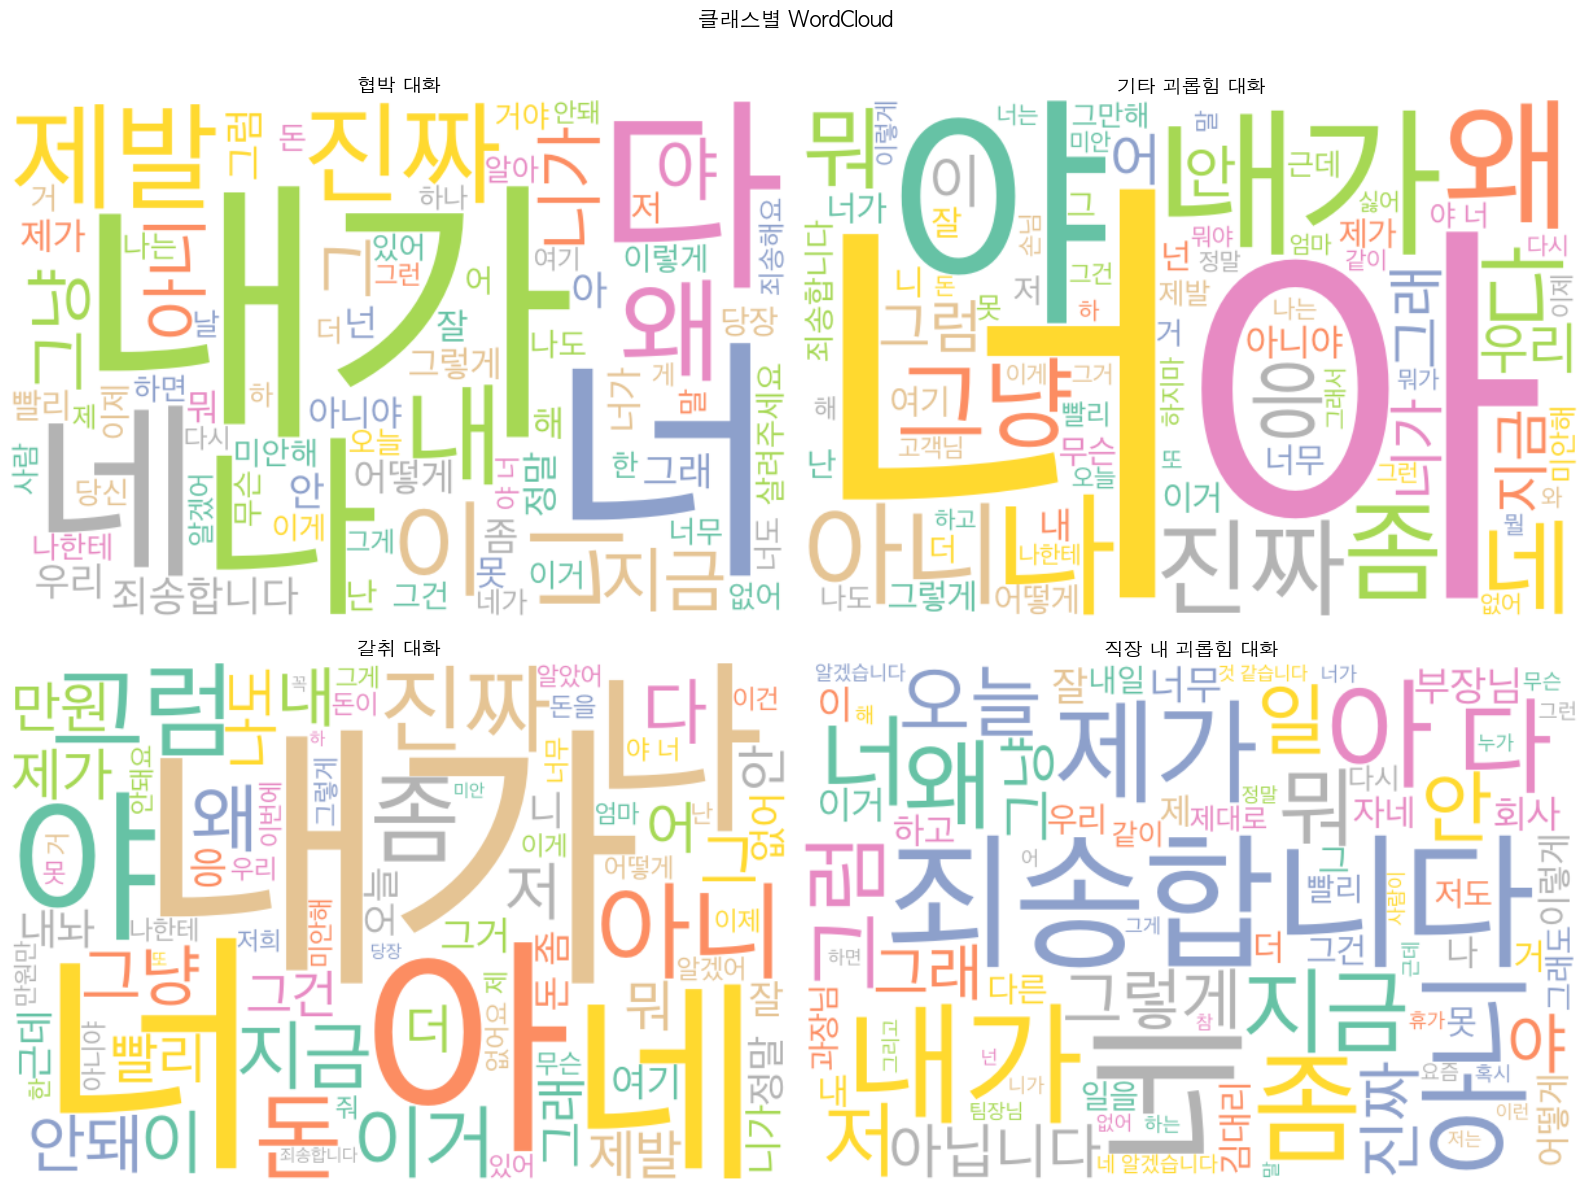

In [10]:
from wordcloud import WordCloud

# macOS 한글 폰트 경로
font_path = '/System/Library/Fonts/AppleSDGothicNeo.ttc'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, cls in zip(axes.flat, train['class'].unique()):
    text = ' '.join(train[train['class'] == cls]['conversation'].values)
    # 한글만 추출
    text = ' '.join(re.findall(r'[가-힣]+', text))
    
    wc = WordCloud(font_path=font_path, width=600, height=400,
                   background_color='white', max_words=80,
                   colormap='Set2').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cls, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('클래스별 WordCloud', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/05_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Test 데이터 분석 (일반 대화 후보 탐색)

In [11]:
# Test 데이터에서 일반 대화로 보이는 샘플 확인
# 위협 키워드가 없는 대화를 찾아보기
threat_keywords = ['죽', '칼', '돈', '내놔', '만원', '때려', '죽여', '살려',
                   '부장', '과장', '찐따', '왕따', '못생']

test['has_threat_kw'] = test['conversation'].apply(
    lambda x: any(kw in x for kw in threat_keywords)
)

print(f'위협 키워드 포함 테스트 샘플: {test["has_threat_kw"].sum()}/{len(test)}')
print(f'위협 키워드 미포함 테스트 샘플: {(~test["has_threat_kw"]).sum()}/{len(test)}')

print('\n=== 위협 키워드 미포함 대화 예시 (일반 대화 후보) ===')
normal_candidates = test[~test['has_threat_kw']].head(5)
for _, row in normal_candidates.iterrows():
    print(f'\n[{row["idx"]}] {row["conversation"][:150]}...')

위협 키워드 포함 테스트 샘플: 266/500
위협 키워드 미포함 테스트 샘플: 234/500

=== 위협 키워드 미포함 대화 예시 (일반 대화 후보) ===

[t_000] 아가씨 담배한갑주소 네 4500원입니다 어 네 지갑어디갔지 에이 버스에서 잃어버렸나보네 그럼 취소할까요 아가씨 내 여기단골이니 담에 갖다줄께 저도 알바생이라 외상안됩니다 아따 누가 떼먹는다고 그러나 갖다준다고 안됩니다 자꾸이럼 경찰불러요 아가씨 담배피는교 그건 왜 물으...

[t_001] 우리팀에서 다른팀으로 갈 사람 없나? 그럼 영지씨가 가는건 어때?  네? 제가요? 그렇지? 2달만 파견 잘 갔다오면 승진이야. 네? 저는 별로 가고 싶지 않습니다. 여기 있는 모든사람도 가기 싫어해. 그러니까 막내인 영지씨가 가는게 맞지 정말 죄송합니다. 저는 못갑니다...

[t_002] 너 오늘 그게 뭐야 네 제가 뭘 잘못했나요.? 제대로 좀 하지 네 똑바로 좀 하지 행실이 맘에 안들어 네 실천할께요 옆에 동기들 좀 본받으란 말야 어? 네 알겠습니다 그래 똑바로해 노럭할께요...

[t_003] 이거 들어바 와 이 노래 진짜 좋다 그치 요즘 이 것만 들어 진짜 너무 좋다 내가 요즘 듣는 것도 들어봐 음 난 좀 별론데 좋을 줄 알았는데 아쉽네 내 취향은 아닌 듯 배고프다 밥이나 먹으러 가자 그래...

[t_004] 아무튼 앞으로 니가 내 와이파이야. .응 와이파이 온. 켰어. 반말? 주인님이라고도 말해야지? .켰습니다. 주인님. 오냐. 앞으로도 잘부탁한다 와이파이. 넵. 이렇게만 해? 알겠지? 응....


## 9. EDA 요약

### 핵심 발견사항

1. **클래스 불균형**: 기타 괴롭힘(1,094) > 갈취(981) > 직장 내 괴롭힘(979) > 협박(896). 일반 대화 클래스 부재
2. **Train/Test 포맷 불일치**: Train 100% 줄바꿈 포함 vs Test 4.8%만 줄바꿈 → **전처리 정규화 필수**
3. **클래스별 키워드 패턴**:
   - 협박: 죽, 칼, 살려 (폭력/생명 위협)
   - 갈취: 돈, 내놔, 만원 (금전 요구)
   - 직장 내 괴롭힘: 회사, 부장, 과장 (직장 맥락)
   - 기타 괴롭힘: 못생, 찐따, 왕따 (인신공격)
4. **합성 데이터 전략**: 일반 대화 생성 시 위 키워드를 피하되, Hard Negative(직장 일상, 돈 관련 일상) 포함 필요